# Dynamics: CESM3 / MOM6 experiment comparison

Diagnostics of the ocean *dynamics* and of the buoyancy / momentum
parameterizations, for a set of coupled and forced experiments. The shared
`Experiment` class lives in `experiment.py` so it can be reused across
notebooks.

**Experiments compared**

| name | mode | data folder |
|------|------|-------------|
| `CTRL` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0_uANN_1.0` | coupled | `data/coupled_55years` |
| `forced_CTRL` | forced | `data/forced_55years` |
| `forced_bANN_1.0` | forced | `data/forced_55years` |
| `forced_bANN_1.0_uANN_1.0` | forced | `data/forced_55years` |

**Figures**

1. Surface isopycnal (Redi) tracer diffusivity `diftrelo`.
2. Parameterized (GM) overturning streamfunction at 1000 m (global maps).
3. APE dissipation by the buoyancy parameterization `MEKE_GM_src`.
4. Energy injection by the ZB2020 momentum scheme in `forced_bANN_1.0_uANN_1.0`.

Heavy quantities are computed once through the `Experiment` class (methods
`compute_*`, reading the raw model history) and cached as
`<folder>/<name>_<metric>.nc`; the plotting cells only read those files.

**Kernel:** `env-from-npl-2024a` (Python 3.11.6).

In [12]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean

from experiment import Experiment

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 18})

# Repo-root-relative paths (this notebook lives in <repo>/notebooks)
REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
YAML_DIR = os.path.join(REPO, 'yamls')
COUPLED_DIR = os.path.join(REPO, 'data', 'coupled_55years')
FORCED_DIR = os.path.join(REPO, 'data', 'forced_55years')
FIG_DIR = os.path.join(REPO, 'figures', 'coupled_55years')

print('REPO       =', REPO)
print('YAML_DIR   =', YAML_DIR)
print('COUPLED_DIR=', COUPLED_DIR)
print('FORCED_DIR =', FORCED_DIR)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
REPO       = /glade/u/home/pavelp/m2lines-CESM3-diagnostics
YAML_DIR   = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/yamls
COUPLED_DIR= /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/coupled_55years
FORCED_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/forced_55years


## Initialize experiments (read-only)

Each experiment is defined by its `name`, the diagnostics YAML config, and the
folder holding its postprocessed NetCDF files. Initialization is read-only: it
only reads config + (best-effort) grid, and never triggers heavy computation.

In [ ]:
# (name, folder) for each experiment. YAML config is yamls/<name>.yaml
experiment_defs = [
    ('CTRL',                        COUPLED_DIR),
    ('coupled_bANN_1.0',            COUPLED_DIR),
    ('coupled_bANN_1.0_uANN_1.0',   COUPLED_DIR),
    ('forced_CTRL',                 FORCED_DIR),
    ('forced_bANN_1.0',             FORCED_DIR),
    ('forced_bANN_1.0_uANN_1.0',    FORCED_DIR),
]

exps = {}
for name, folder in experiment_defs:
    yaml_path = os.path.join(YAML_DIR, f'{name}.yaml')
    exps[name] = Experiment(yaml_path, folder=folder, name=name,
                            load_grid=True, verbose=True)

exp_names = list(exps.keys())
print('\nInitialized:', exp_names)

[CTRL] casename=CTRL, rundir=/glade/derecho/scratch/jiarongw/CTRL/run


ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/pavelp/conda-envs/env-from-npl-2024a/share/proj failed


MOM6 grid successfully loaded... 

[coupled_bANN_1.0] casename=coupled_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0/run
MOM6 grid successfully loaded... 

[coupled_bANN_1.0_uANN_1.0] casename=coupled_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 

[forced_CTRL] casename=forced_CTRL, rundir=/glade/derecho/scratch/pavelp/forced_CTRL/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0] casename=forced_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0_uANN_1.0] casename=forced_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 


Initialized: ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0', 'forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']


In [17]:
# Column order: GM (left), bANN (center), bANN_uANN (right)
coupled_names = ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0']
forced_names = ['forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']

In [18]:
# Short legend labels (regime is shown in the panel title, so it is omitted here)
LABELS = {
    'CTRL':                       'GM',
    'coupled_bANN_1.0':           'bANN',
    'coupled_bANN_1.0_uANN_1.0':  'bANN_uANN',
    'forced_CTRL':                'GM',
    'forced_bANN_1.0':            'bANN',
    'forced_bANN_1.0_uANN_1.0':   'bANN_uANN',
}

# 1. Surface isopycnal (Redi) diffusivity

Horizontal maps of the surface epineutral tracer diffusivity `diftrelo`
(Ocean Tracer Epineutral Laplacian Diffusivity, m^2 s^-1), time-averaged over
model years 50-54 (surface interface, zi = 0 m). This is the isopycnal (Redi)
diffusivity applied by the tracer-mixing scheme, useful for contrasting the GM
control against the (b)ANN parameterizations.

The first cell computes and caches the surface field to
`<folder>/<name>_diftrelo_surface.nc` (heavy: reads the raw native history for
each experiment; experiments already cached, or without native output, are
skipped). The second cell plots them.

In [ ]:
# Compute (and cache) the time-mean surface epineutral diffusivity for every
# experiment. Reads raw native history -> heavy step; skips any experiment
# already cached (or without native output on disk).
for name in exp_names:
    exp = exps[name]
    try:
        exp.compute_diftrelo_surface()
    except Exception:
        print(f'{name} skipped')

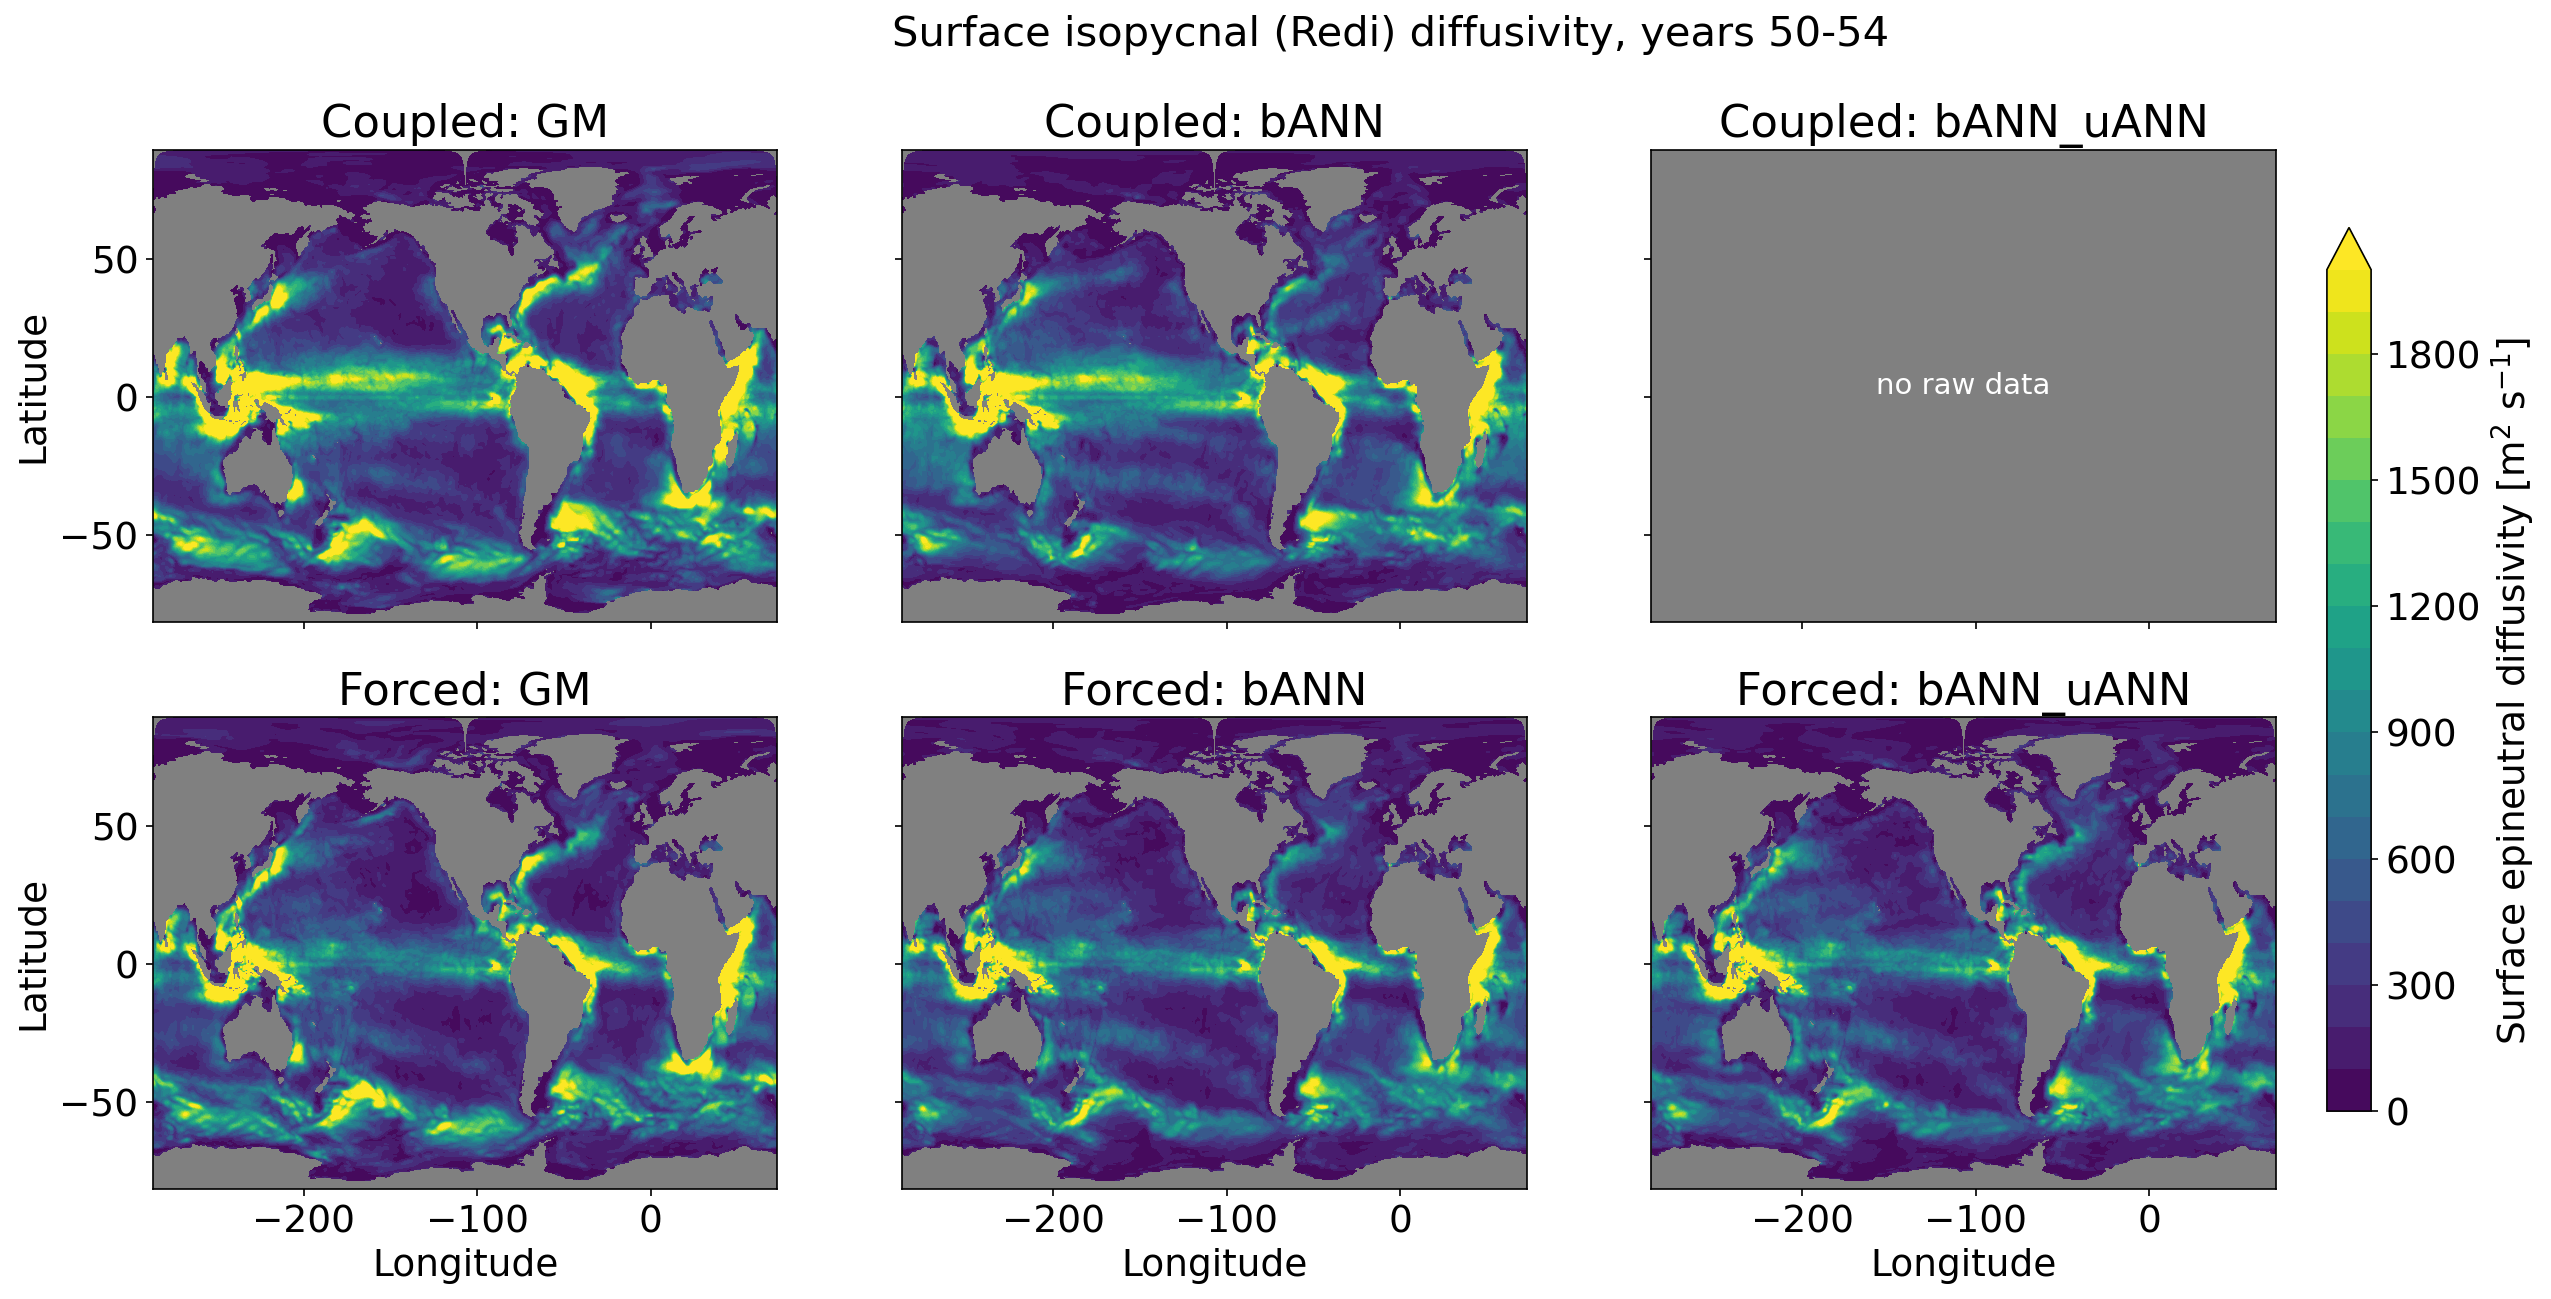

In [19]:
# Surface epineutral (Redi) diffusivity maps: 2x3 grid
# (coupled top / forced bottom). Plotted on the curvilinear (geolon, geolat)
# grid so the tripolar cap is rendered correctly.
DIFF_LEVELS = np.arange(0, 2001, 100)   # m^2 s^-1

fig, axes = plt.subplots(2, 3, figsize=(22, 9), dpi=150,
                         sharex=True, sharey=True)
cf = None
for row, (regime, names) in enumerate([('Coupled', coupled_names),
                                       ('Forced', forced_names)]):
    for col, name in enumerate(names):
        ax = axes[row, col]
        ax.set_facecolor('gray')
        try:
            field = exps[name].diftrelo_surface()
            grd = exps[name].grd
            cf = ax.contourf(grd.geolon, grd.geolat, field, levels=DIFF_LEVELS,
                             cmap='viridis', extend='max')
            ax.set_xlim(float(grd.geolon.min()), float(grd.geolon.max()))
            ax.set_ylim(float(grd.geolat.min()), float(grd.geolat.max()))
        except (FileNotFoundError, KeyError):
            ax.text(0.5, 0.5, 'no raw data', ha='center', va='center',
                    transform=ax.transAxes, color='white', fontsize=14)
        ax.set_title(f'{regime}: {LABELS[name]}')
        ax.set_xlabel('Longitude' if row == 1 else '')
        ax.set_ylabel('Latitude' if col == 0 else '')
if cf is not None:
    fig.colorbar(cf, ax=axes, label=r'Surface epineutral diffusivity [m$^2$ s$^{-1}$]',
                 extend='max', shrink=0.85, pad=0.02)
fig.suptitle(r'Surface isopycnal (Redi) diffusivity, years 50-54', fontsize=20)
plt.show()

# 2. Parameterized (GM) overturning at 1000 m

Global maps of the *parameterized* (GM) overturning streamfunction at 1000 m
depth. For each experiment the parameterized meridional bolus transport `vhGM`
(kg s^-1) is read from the z-coordinate history (`*.mom6.h.z.*`), averaged over
the standard window, converted to Sv and vertically accumulated from the bottom
to give a local overturning streamfunction; the layer nearest 1000 m is plotted
(see `spatial_overturning.ipynb`).

The first cell computes and caches each map to
`<folder>/<name>_gm_overturning_1km.nc`; the second plots the six experiments.

In [20]:
# Compute (and cache) the parameterized GM overturning at 1 km for every
# experiment. Reads raw z-coordinate history -> heavy; skips cached / missing.
for name in exp_names:
    exp = exps[name]
    try:
        exp.compute_gm_overturning_1km()
    except Exception as e:
        print(f'{name} skipped ({e})')

[########################################] | 100% Completed | 45.66 s
[########################################] | 100% Completed | 45.42 s
coupled_bANN_1.0_uANN_1.0 skipped (no files to open)
[########################################] | 100% Completed | 46.42 s
[########################################] | 100% Completed | 45.36 s
[########################################] | 100% Completed | 47.98 s


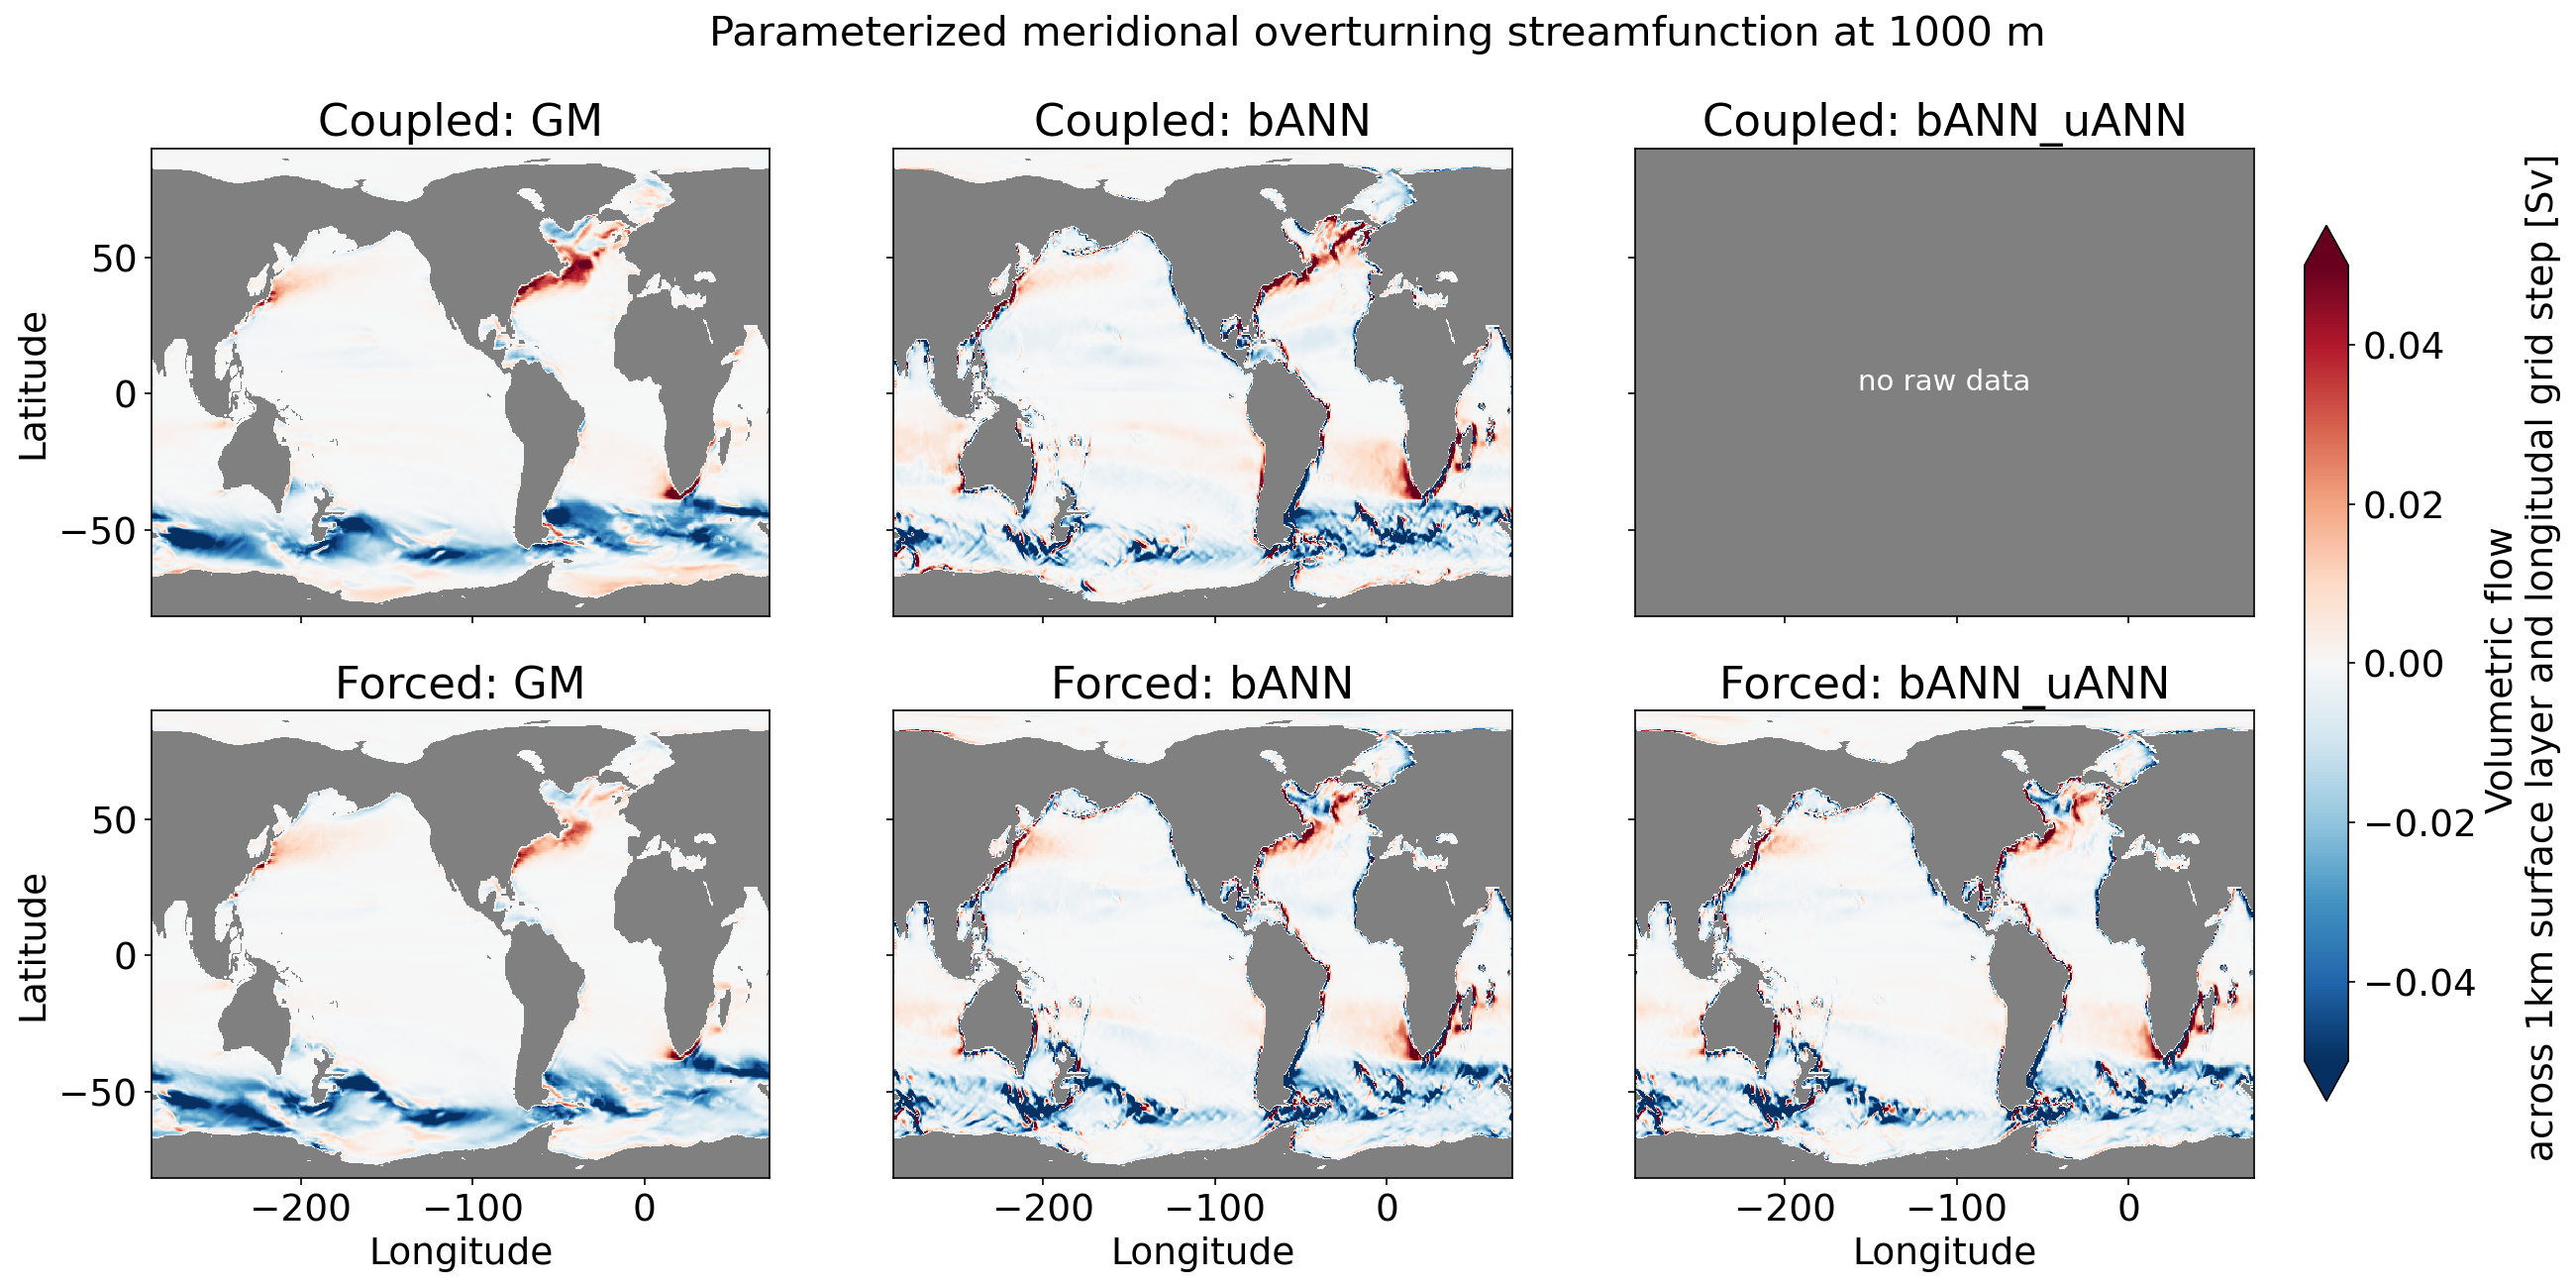

In [37]:
# Parameterized GM overturning at 1 km: 2x3 global maps (coupled / forced).
PSI_LIM = 0.05   # Sv

fig, axes = plt.subplots(2, 3, figsize=(22, 9), dpi=150,
                         sharex=True, sharey=True)
pm = None
for row, (regime, names) in enumerate([('Coupled', coupled_names),
                                       ('Forced', forced_names)]):
    for col, name in enumerate(names):
        ax = axes[row, col]
        ax.set_facecolor('gray')
        try:
            ds = exps[name].gm_overturning_1km()
            pm = ax.pcolormesh(ds.geolonv, ds.geolatv, ds.psi_gm_1km,
                               cmap='RdBu_r', vmin=-PSI_LIM, vmax=PSI_LIM,
                               shading='auto')
            ax.set_xlim(float(ds.geolonv.min()), float(ds.geolonv.max()))
            ax.set_ylim(float(ds.geolatv.min()), float(ds.geolatv.max()))
        except (FileNotFoundError, KeyError):
            ax.text(0.5, 0.5, 'no raw data', ha='center', va='center',
                    transform=ax.transAxes, color='white', fontsize=14)
        ax.set_title(f'{regime}: {LABELS[name]}')
        ax.set_xlabel('Longitude' if row == 1 else '')
        ax.set_ylabel('Latitude' if col == 0 else '')
        #ax.set_ylim([20,70])
        #ax.set_xlim([-80,0])
if pm is not None:
    fig.colorbar(pm, ax=axes, label='Volumetric flow \n across 1km surface layer and longitudal grid step [Sv]',
                 extend='both', shrink=0.85, pad=0.02)
fig.suptitle(r'Parameterized meridional overturning streamfunction at 1000 m',
             fontsize=20)
plt.show()

# 3. APE dissipation by the buoyancy parameterization

Time-mean maps of `MEKE_GM_src` (W m^-2), the source of mesoscale eddy kinetic
energy extracted from the available potential energy by the GM / MEKE buoyancy
parameterization (see the `MEKE_GM_src` maps in
[compare_runs_coupled.ipynb](../notebooks-development/compare_runs_coupled.ipynb)).
It is already a vertically-integrated 2-D field in the native output.

The first cell computes and caches each map to
`<folder>/<name>_meke_gm_src.nc`; the second plots the six experiments.

In [8]:
# Compute (and cache) the time-mean MEKE_GM_src for every experiment.
# Reads raw native history -> heavy; skips cached / missing.
for name in exp_names:
    exp = exps[name]
    try:
        exp.compute_meke_gm_src()
    except Exception as e:
        print(f'{name} skipped ({e})')

CTRL skipped ('MEKE_GM_src')
[########################################] | 100% Completed | 43.15 s
coupled_bANN_1.0_uANN_1.0 skipped (no files to open)
[########################################] | 100% Completed | 50.01 s
[########################################] | 100% Completed | 48.65 s
[########################################] | 100% Completed | 53.66 s


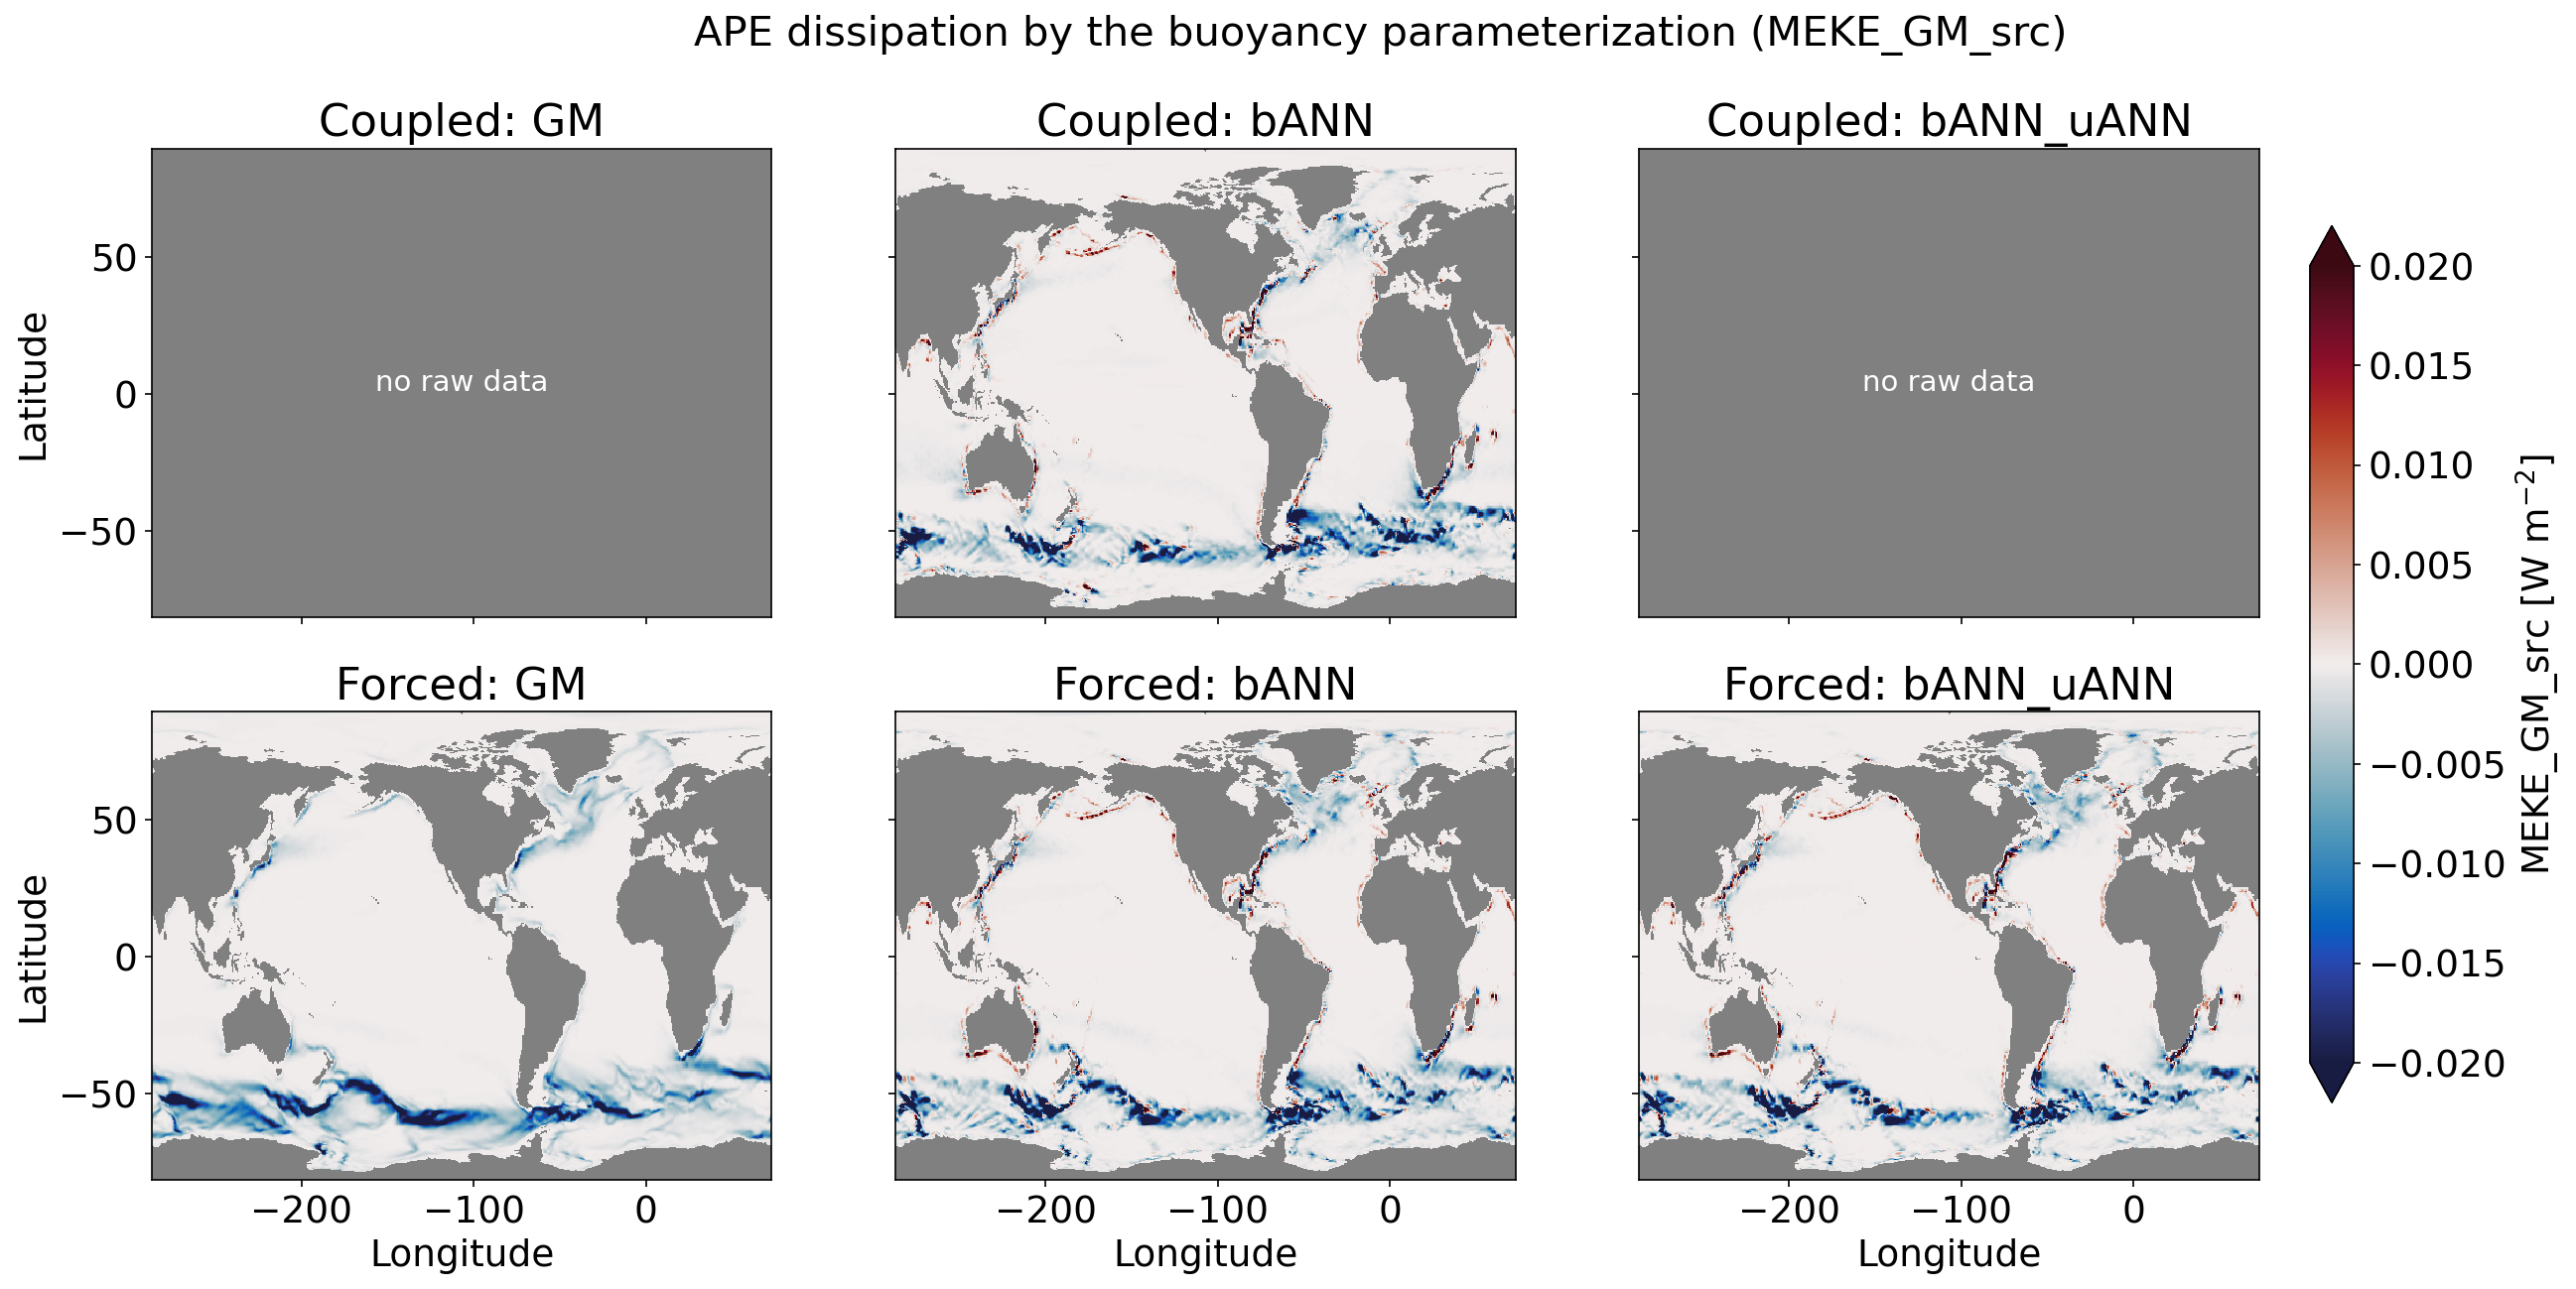

In [38]:
# APE dissipation MEKE_GM_src: 2x3 maps (coupled / forced).
MEKE_LIM = 0.02   # W m^-2

fig, axes = plt.subplots(2, 3, figsize=(22, 9), dpi=150,
                         sharex=True, sharey=True)
pm = None
for row, (regime, names) in enumerate([('Coupled', coupled_names),
                                       ('Forced', forced_names)]):
    for col, name in enumerate(names):
        ax = axes[row, col]
        ax.set_facecolor('gray')
        try:
            field = exps[name].meke_gm_src()
            grd = exps[name].grd
            pm = ax.pcolormesh(grd.geolon, grd.geolat, field,
                               cmap=cmocean.cm.balance,
                               vmin=-MEKE_LIM, vmax=MEKE_LIM, shading='auto')
            ax.set_xlim(float(grd.geolon.min()), float(grd.geolon.max()))
            ax.set_ylim(float(grd.geolat.min()), float(grd.geolat.max()))
        except (FileNotFoundError, KeyError):
            ax.text(0.5, 0.5, 'no raw data', ha='center', va='center',
                    transform=ax.transAxes, color='white', fontsize=14)
        ax.set_title(f'{regime}: {LABELS[name]}')
        ax.set_xlabel('Longitude' if row == 1 else '')
        ax.set_ylabel('Latitude' if col == 0 else '')
if pm is not None:
    fig.colorbar(pm, ax=axes, label=r'MEKE_GM_src [W m$^{-2}$]',
                 extend='both', shrink=0.85, pad=0.02)
fig.suptitle(r'APE dissipation by the buoyancy parameterization (MEKE_GM_src)',
             fontsize=20)
plt.show()

# 4. Energy injection by the uANN momentum scheme

Single-panel map of where the ZB2020 momentum parameterization injects energy in
`forced_bANN_1.0_uANN_1.0`. The column-integrated energy-injection rate is
`rho0 * KE_ZB2020.sum('z_l')` with `rho0 = 1023` kg m^-3, giving W m^-2, where
`KE_ZB2020` (m^3 s^-3) is read from the z-coordinate history (`*.mom6.h.z.*`)
and time-averaged over the standard window.

The first cell computes and caches the map to
`<folder>/<name>_ke_zb2020_vertsum.nc`; the second plots it.

In [ ]:
# Compute (and cache) the vertically-integrated ZB2020 energy injection for
# the momentum-flux experiment. Reads raw z-coordinate history -> heavy.
ZB_NAME = 'forced_bANN_1.0_uANN_1.0'
try:
    exps[ZB_NAME].compute_ke_zb2020_vertsum()
except Exception as e:
    print(f'{ZB_NAME} skipped ({e})')

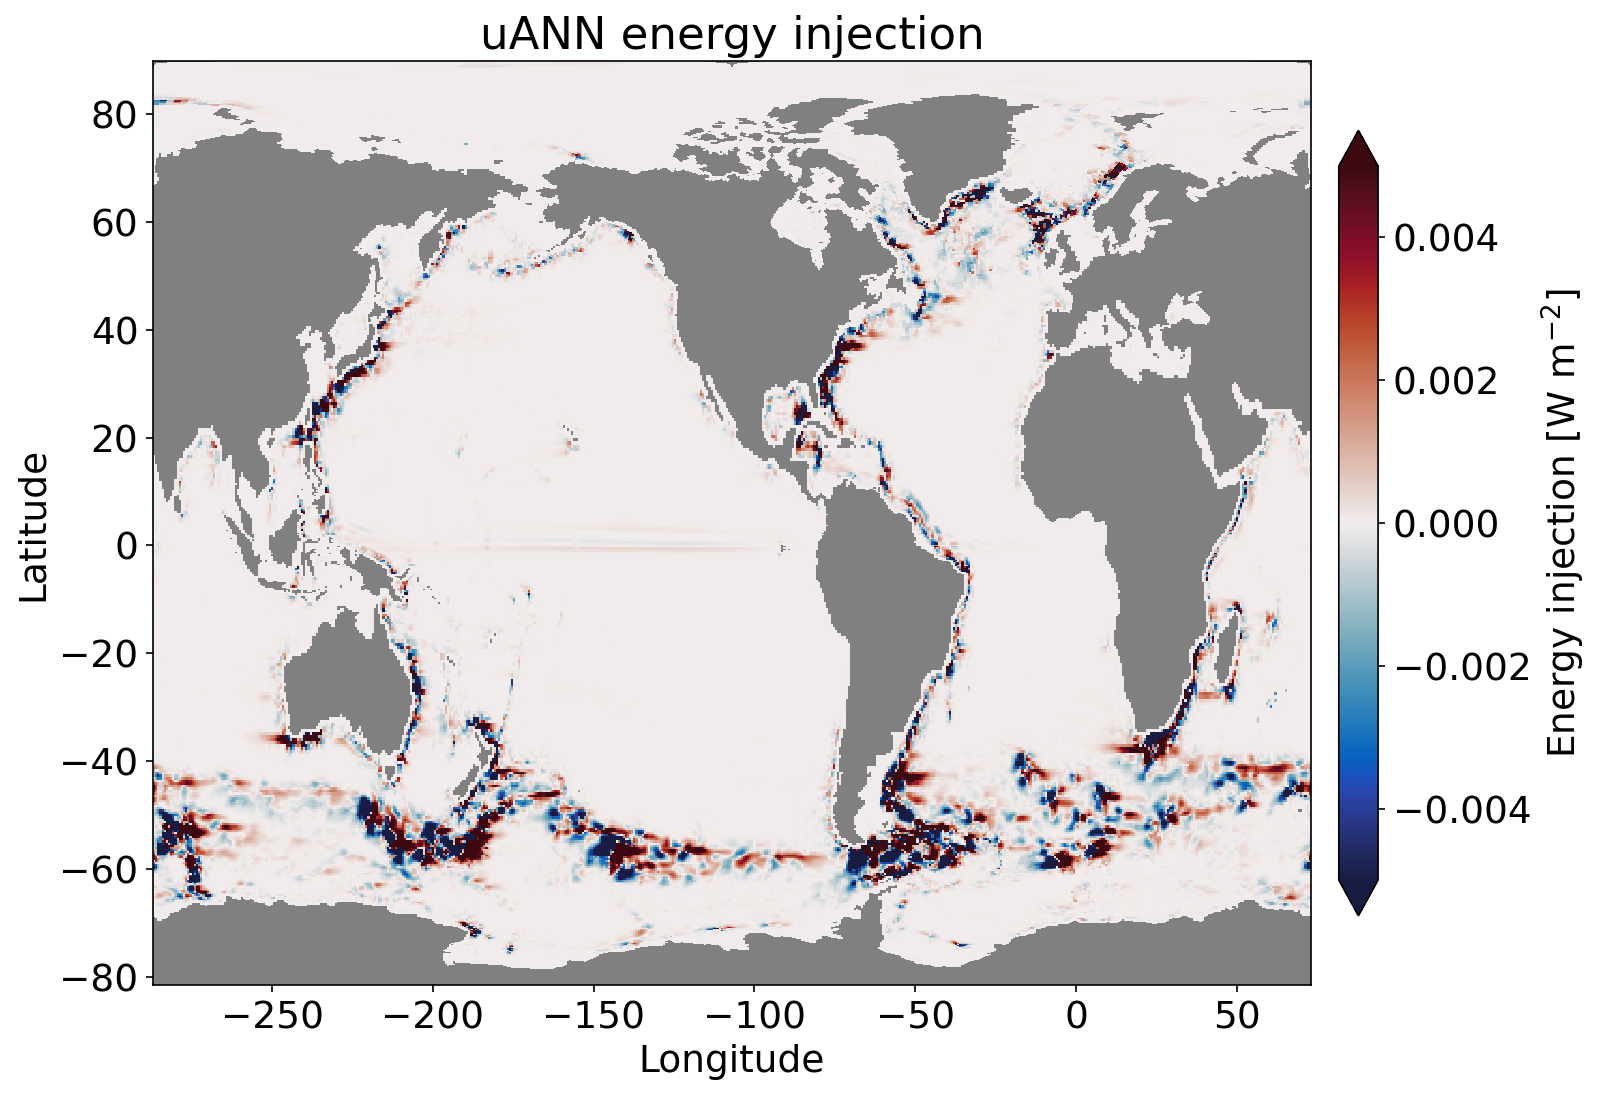

In [54]:
# ZB2020 energy injection: single-panel map.
field = exps[ZB_NAME].ke_zb2020_vertsum()
grd = exps[ZB_NAME].grd

#lim = float(np.nanpercentile(np.abs(field.values), 99))
lim=0.005

fig, ax = plt.subplots(figsize=(12, 8), dpi=150)
ax.set_facecolor('gray')
pm = ax.pcolormesh(grd.geolon, grd.geolat, field,
                   cmap=cmocean.cm.balance, vmin=-lim, vmax=lim, shading='auto')
ax.set_xlim(float(grd.geolon.min()), float(grd.geolon.max()))
ax.set_ylim(float(grd.geolat.min()), float(grd.geolat.max()))
fig.colorbar(pm, ax=ax, label=r'Energy injection [W m$^{-2}$]',
             extend='both', shrink=0.85, pad=0.02)
ax.set_title(f'uANN energy injection')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()